In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as c
from scipy.signal import fftconvolve
from q3dfit.q3din import q3din
from q3dfit.q3dout import q3dout, load_q3dout
from q3dfit.q3df import q3dfit
from q3dfit import q3dutil
from q3dfit.checkcomp import checkcomp
from q3dfit.q3dcollect import q3dcollect
from q3dfit.linelist import linelist

# Setup

In [50]:
# global parameters
label = "4C1971"
infile = "4C1971_G235H_NRS1_NRS2_s3d.fits"
outdir = "output"
# init_n_gauss_fit(2, infile)
label_conv = label+"_conv"
infile_conv = label+"_convolved.fits"
outdir_conv = outdir+"_conv"
redshift = 3.5892
fitrange = [2.16, 2.375]
ncores = 22

# infile_wo_cont = label+"_wo_continuum.fits"
# infile_converted_units = label+"_converted_units.fits"

indir = "input"
logdir = "logfiles"
if not os.path.exists(indir):
    os.makedirs(indir)

cols, rows = None, None
# lines to fit (name & wavelength)
lines = ['Hbeta', '[OIII]4959', '[OIII]5007']
line_wavelengths = list(linelist(lines)["lines"]) # micron
c_kms = c.c.to("km/s").value

In [27]:
def micron_to_redshift(l, l0):
    return l/l0 - 1 

In [49]:
def init_n_gauss_fit(n :int, infile: str, label: str, outdir: str) -> str:
    assert n > 0, f"n={n}: n must be a positive integer"
    assert os.path.exists(infile), f"{infile} doesn't exist"

    # set up directories
    outdir_n = outdir + str(n) + "/"
    if not os.path.exists(outdir_n):
        os.makedirs(outdir_n)
    logdir_n = logdir + str(n) + "/"
    if not os.path.exists(logdir_n):
        os.makedirs(logdir_n)

    # create q3di object and set important parameters
    logfile = os.path.join(logdir_n, label+"-fitlog.txt")
    q3di = q3din(infile, label, outdir=outdir_n, logfile=logfile)
    q3di.argsreadcube = {"wmapext": None, "fluxnorm": 1e-17, "usebunit": True}
    cube = q3di.load_cube()
    q3di.name = label
    q3di.zsys_gas = redshift
    q3di.fitrange = fitrange

    # line fit
    q3di.init_linefit(lines, linetie='[OIII]5007', maxncomp=n, checkcomp=False)
    q3di.spect_convol['ws_instrum'] = {'JWST_NIRSPEC':['G235H']}
    q3di.siglim_gas = np.array([40., 1000.])
    # q3di.argslineinit['flxlim'] = np.array([0., 1e-14]) / cube.fluxnorm
    q3di.argslinefit['method'] = 'least_squares'
    q3di.argslinefit['ftol'] = 1.e-8
    q3di.argslinefit['gtol'] = 1.e-8
    q3di.argslinefit['xtol'] = 1.e-8
    q3di.argslinefit['x_scale'] = 'jac'
    q3di.argslinefit['tr_solver'] = 'lsmr'

    q3di.argscheckcomp['sigcut'] = 3.
    q3di.argscheckcomp['ignore']= ['Hbeta']
    q3di.perror_useresid = True

    q3di.snr = 3.0
    # if n == 1:
    #     q3di.snr_thresh = {'snr_thresh': 3.0, # Set relative low SNR to not omit broad components
    #             'line_mask': None, # This has to be computed later with the onecomp fit
    #             'peak_or_int': 'peak'} # Do not change
    # else:
    #     q3di.snr_thresh = {'snr_thresh': 3.0, 
    #             'line_mask': None, 
    #             'peak_or_int': 'peak'}
    q3di.snr_thresh = None

    for line in lines:
        q3di.siginit_gas[line][:,:,:] = 200.
    # line fit inital parameters for n>1
    if n > 1:
        previous_data = np.load(os.path.join(outdir+str(n-1), label+".line.npz"), allow_pickle=True)

        for line, w in zip(lines, line_wavelengths):
            for i in range(n-1):
                init_val = micron_to_redshift(previous_data["emlwav"][None][0][f"c{i+1}"][line], w)
                q3di.zinit_gas[line][:,:,i][~np.isnan(init_val)] = init_val[~np.isnan(init_val)]
                init_sig = np.clip(previous_data["emlsig"][None][0][f"c{i+1}"][line], *q3di.siglim_gas)
                q3di.siginit_gas[line][:,:,i][~np.isnan(init_sig)] = init_sig[~np.isnan(init_sig)]

        res_data = np.load(os.path.join(outdir+str(n-1), "max_res.npy"))
        res_val = micron_to_redshift(res_data, line_wavelengths[2])
        q3di.zinit_gas["[OIII]5007"][:,:,n-1][~np.isnan(res_val)] = res_val[~np.isnan(res_val)]

        # plt.imshow(init_val.T, origin="lower")
        # plt.colorbar()
        # plt.show()
        # print(np.nanmin(init_val), np.nanmax(init_val))
        # plt.imshow(previous_data["emlwav"][None][0][f"c{i+1}"][line].T, origin="lower")
        # plt.colorbar()
        # plt.show()

    # continum fit
    # if n == 1:
    q3di.init_contfit("fitpoly")
    q3di.argscontfit.update({"fitord": 1})
    # else:
    #     q3di.init_contfit("fitpoly")
    #     q3di.docontfit = False
    q3di.maskwidths_def = 4000
    q3di.masksig_secondfit = 4

    filename_q3di = os.path.join(indir, f"q3di_{label}_{n}.npy")
    np.save(filename_q3di, q3di)
    return filename_q3di

# Fit 1 Gauss and Continuum

In [29]:
# init fit
# filename_q3di = init_n_gauss_fit(1, infile)
# q3dfit(filename_q3di, cols, rows, onefit=True, nocrash=True, quiet=False, ncores=ncores)

In [ ]:
filename_q3di = init_n_gauss_fit(1, infile_conv, label_conv, outdir_conv)
q3di = q3dutil.get_q3dio(filename_q3di)
# q3dfit(filename_q3di, 18, 33, onefit=True, quiet=False)

Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: erg/s/cm2/micron
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.


In [31]:
# cube, _ = q3dutil.get_Cube(q3di)
# data = cube.dat
# var = cube.var
# def myfftconvolve(data, kernel, axes, mode):
#     mask = ~np.isnan(data)
#     return np.where(mask, fftconvolve(np.where(mask, data, 0), kernel, axes=axes, mode=mode), np.nan)

# from astropy.io import fits
# with fits.open(infile) as hdul:
#     hdul.info()
#     hdul[1].data = data.T * cube.fluxnorm
#     hdul[1].header["BUNIT"] = "erg/s/cm2/micron"
#     hdul[2].data = var.T * cube.fluxnorm**2
#     hdul[2].header["BUNIT"] = "erg/s/cm2/micron"
#     hdul.writeto(infile_converted_units, overwrite=True)

#     kernel = np.ones((3, 3, data.shape[2]))
#     conv = myfftconvolve(data, kernel, axes=(0,1), mode="same")
#     hdul[1].data = conv.T * cube.fluxnorm
#     conv_err = myfftconvolve(var, kernel, axes=(0,1), mode="same")
#     hdul[2].data = conv_err.T * cube.fluxnorm**2
#     hdul.writeto(infile_convoled, overwrite=True)

In [32]:
number_of_components = np.zeros((10, q3di.ncols, q3di.nrows))
aic_array = np.full((10, q3di.ncols, q3di.nrows), np.nan, dtype="float64")

In [33]:
from scipy import stats
def decide_fit_quality(q3do, weighting=None, num_samples=10000, plots=False, axs=None):
    '''
    This function takes a q3do object and returns a boolean value indicating if the fit is good.
    The function uses the Kolmogorov-Smirnov test and the Acharya test to determine the quality of the fit.

    Inputs:
    q3do: q3dout object
    weighting: Literal ['None', 'flux_error', 'flux_data']
                - None: no weighting
                - flux_error: divide residuals by the flux error
                - flux_data: divide residuals by the sum of the data and fit flux
    num_samples: int - the number of samples to use for the Acharya test
    plots: bool - if True, plots the residuals and the simulated residuals

    Returns:
    fit_is_good_bool: bool - True if the fit is good, False if the fit is bad
    ks_p: float - the p-value of the Kolmogorov-Smirnov test
    pcum: float - the p-value of the Acharya test
    '''

    # Calculate residuals depending on the weighting
    wave = q3do.wave
    #emission_mask, central_wavelengths, wvl_sigmas = emission_line_pars(q3do,3)

    residuals = q3do.line_dat-q3do.line_fit
    #residuals_lines = residuals[emission_mask]
    if weighting == 'flux_error':
        residuals = residuals/q3do.spec_err
        #residuals_lines = residuals_lines/q3do.spec_err[emission_mask]
    elif weighting == 'flux_data':
        raise ValueError('flux_data should maybe only be line data not cont data')
        residuals = residuals/(q3do.line_fit+q3do.cont_fit)
        #residuals_lines = residuals_lines/(q3do.line_fit[emission_mask]+q3do.cont_fit[emission_mask])
    elif weighting is not None:
        raise ValueError('Invalid weighting type')

    # Remove NaN values from the residuals and all other arrays
    number_of_nans = np.isnan(residuals).sum()
    #print(f'Number of nans in residuals: {number_of_nans}')
    wave = wave[~np.isnan(residuals)]
    residuals = residuals[~np.isnan(residuals)]
    #emission_mask = emission_mask[~np.isnan(residuals)]
    #residuals_lines = residuals_lines[~np.isnan(residuals_lines)]
        
    # Calculate the properties of the residuals
    residual_mean = np.nanmean(residuals)
    residual_std = np.nanstd(residuals)
    n = len(residuals)
    cumsum_obs = np.nancumsum(residuals)

    # Perform the Kolmogorov-Smirnov test
    ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(residual_mean, residual_std), nan_policy='omit')
    #ks_stat_l, ks_p_l = stats.kstest(residuals_lines, 'norm', args=(np.mean(residuals_lines), np.std(residuals_lines)), nan_policy='omit')

    # Perform the Acharya test
    # First simulate the residuals (gaussian)
    simulated_res = np.random.normal(residual_mean, residual_std, (num_samples, n))
    simulated_cumsums = np.cumsum(simulated_res, axis=1)
    # Compute the 5th and 95th percentiles
    perc_05 = np.percentile(simulated_cumsums, 5, axis=0)
    perc_95 = np.percentile(simulated_cumsums, 95, axis=0)
    # Count how many observed CUMSum values are outside the 5th and 95th percentile
    outliers = np.sum((cumsum_obs < perc_05) | (cumsum_obs > perc_95))
    # Claculate the P_cumsum value
    pcum = outliers / n

    # Determine if the fit is good
    # The ratio of the KS-test p-value and the Acharya test p-value is used to determine the fit quality
    # We combine the two p-values to to account if one of the tests is very confident
    # Because KS-test is more relevant we always want it to be above the critical value 0.05
    p_value_together = ks_p + 1 - pcum

    if ks_p > 0.1:
        fit_is_good_bool = True
    elif p_value_together >= 1.05: # implies ks_p > 0.1 for any pcum
        fit_is_good_bool = True
    else:
        fit_is_good_bool = False

    if plots:
        if axs is None:
            fig, axs = plt.subplots(2, 1, figsize=(8, 6))
        # Residuals and Cumulative Sum
        for i in range(100):
            cumsum_residuals_sim = np.cumsum(simulated_res[i])
            axs[0].plot(wave, cumsum_residuals_sim, color='gray', alpha=0.5)
        axs[0].plot(wave, perc_05, color='blue', label='5th Percentiles')
        axs[0].plot(wave, perc_95, color='blue')
        axs[0].plot(wave, cumsum_obs, color='red', label='Observed Cumulative Sum')
        axs[0].plot(wave, residuals, color='black', label='Observed Residuals')
        axs[0].legend(loc='upper left')
        axs[0].set_xlabel('Wavelength [Å]')
        axs[0].set_ylabel('Residuals')
        axs[0].set_title('Acharya Test')
        axs[0].grid(True)
        axs[0].text(0.01, 0.1, f'Acharya P-value: {pcum:.4f}', transform=axs[0].transAxes, fontsize=12, color='blue', fontweight='bold')

        # KS-test plot
        axs[1].step(np.sort(residuals), np.arange(1, n+1) / n, color='red', label='Observed CDF', where='post')
        #axs[1].step(np.sort(residuals_lines), np.arange(1, len(residuals_lines)+1) / len(residuals_lines), color='red', label='Empirical CDF', where='post', ls='--')
        axs[1].plot(np.sort(residuals), stats.norm.cdf(np.sort(residuals), loc=residual_mean, scale=residual_std), 
                    color='black', label='Gaussian CDF')
        #axs[1].plot(np.sort(residuals_lines), stats.norm.cdf(np.sort(residuals_lines), loc=np.mean(residuals_lines), scale=np.std(residuals_lines)),
                    #color='black', label='Gaussian CDF', ls='--')
        # Mark the KS statistic
        max_diff_index = np.argmax(np.abs((np.arange(1, n+1) / n) - stats.norm.cdf(np.sort(residuals), loc=residual_mean, scale=residual_std)))
        axs[1].vlines(np.sort(residuals)[max_diff_index], (np.arange(1, n+1) / n)[max_diff_index], 
                      stats.norm.cdf(np.sort(residuals)[max_diff_index], loc=residual_mean, scale=residual_std), 
                      color='blue', linestyle='-', linewidth=2)   
        # Mark the KS statistic for the lines
        #max_diff_index = np.argmax(np.abs((np.arange(1, len(residuals_lines)+1) / len(residuals_lines)) - stats.norm.cdf(np.sort(residuals_lines), loc=np.mean(residuals_lines), scale=np.std(residuals_lines))))
        # axs[1].vlines(np.sort(residuals_lines)[max_diff_index], (np.arange(1, len(residuals_lines)+1) / len(residuals_lines))[max_diff_index],
        #                 stats.norm.cdf(np.sort(residuals_lines)[max_diff_index], loc=np.mean(residuals_lines), scale=np.std(residuals_lines)),
        #                 color='blue', linestyle='-', linewidth=2)
        # Labels
        axs[1].set_xlabel("Residuals")
        axs[1].set_ylabel("CDF")
        axs[1].set_title("Kolmogorov-Smirnov Test")
        axs[1].legend()
        axs[1].grid(True)
        axs[1].text(0.05, 0.7, f'KS P-value: {ks_p:.4f}', transform=axs[1].transAxes, fontsize=12, color='blue', fontweight='bold')
        axs[1].text(0.05, 0.6, f'Added P-value: {ks_p+1-pcum:.4f}', transform=axs[1].transAxes, fontsize=12, color='blue', fontweight='bold')

        # get snr ratio and text it
        # snr_list, snr_peak_list = get_snr_from_fits('TNJ0121_1320cal_g235h-f170lp_s3d_cleaned_wcs_corrbkgr_sub_conv.fits',
        #                                             'tnj0121_1320',
        #                                             'output/fits_output/final_fits/',
        #                                             q3do.col, q3do.row,
        #                                             q3do
        #                                             )
        # snr_int, snr_peak = np.nanmin(snr_list), np.nanmin(snr_peak_list)
        # axs[1].text(0.05, 0.5, f'SNR int: {snr_int:.2f}', transform=axs[1].transAxes, fontsize=12, color='blue', fontweight='bold')
        # axs[1].text(0.05, 0.4, f'SNR pk: {snr_peak:.2f}', transform=axs[1].transAxes, fontsize=12, color='blue', fontweight='bold')
      
        plt.tight_layout()
        #plt.savefig(f'output/fits_output/final_fits/{q3do.col:04d}_{q3do.row:04d}_{q3do.maxncomp}.png')

        plt.show()

    # If the boundaries of the fit are reached, the fit is not considered good
    sigmas = [v for k, v in q3do.param.items() if "_sig" in k]
    if np.any(np.isclose(np.array(sigmas), q3do.siglim[0], atol=2)) or np.any(np.isclose(np.array(sigmas), q3do.siglim[1], atol=2)):
        #print(f'{q3do.col} {q3do.row} is not good because the boundaries of the fit are reached')
        #print(f"{q3do.maxncomp} with sigmas: {sigmas}")
        return False, 0, 1
    
    # Now check for SNR cut
    # only check highest SNR line, but all components
    flxs_mxs = [np.nanmax([v for k, v in q3do.param.items() if f"{i}_flx" in k]) for i in range(q3do.maxncomp)]
    flux_lim = np.nanmax([v.min for k, v in q3do.parinit.items() if "_flx" in k])

    if np.any(np.isclose(np.array(flxs_mxs), flux_lim, atol=0.05*flux_lim)):
        #print(f'{q3do.col} {q3do.row} is not good because the flux limit is reached')
        #print(f"{q3do.maxncomp} with fluxes: {flxs_mxs}")
        return False, 0, 1

    return fit_is_good_bool, ks_p, pcum, 

In [34]:
from functools import partial
import multiprocessing
# check componets for significance
def check_with_checkcomp(ispax, colarr, rowarr, q3di, quiet):
    i = colarr[ispax]
    j = rowarr[ispax]
    try:
        q3do: q3dout = load_q3dout(q3di, i+1, j+1)
    except FileNotFoundError:
        return
    if not q3do.dolinefit:
        return
    # print(i, j)
    # execute checkcomp manually
    q3do.sepfitpars()
    ncomp = dict()
    for line in q3di.lines:
        ncomp[line] = q3di.ncomp[line][i, j]
    try:    
        newncomp = checkcomp(q3do.line_fitpars, q3di.linetie, ncomp.copy(), q3do.siglim, **q3di.argscheckcomp)
    except AttributeError:
        return

    # discard bad fits
    for line, newncomp_value in newncomp.items():
        if ncomp[line] > newncomp_value:
            q3do.discard = True
            np.save(q3do.filelab, q3do)
            if not quiet:
                print(f"Discarded [{int(i+1)}, {int(j+1)}]")
            break
    else:
        q3do.discard = False
        np.save(q3do.filelab, q3do)

        return get_max_residual(q3do)
    
def check_with_kstest(ispax, colarr, rowarr, q3di, quiet):
    i = colarr[ispax]
    j = rowarr[ispax]
    try:
        q3do: q3dout = load_q3dout(q3di, i+1, j+1)
    except FileNotFoundError:
        return
    if not q3do.dolinefit:
        return
    
    # perform kolmogorow-smirnow test
    fit_is_good, ks_p, pcum = decide_fit_quality(q3do)
    if fit_is_good:
        return
    else:
        return get_max_residual(q3do)
    
def check_with_aic(ispax, colarr, rowarr, q3di, quiet, previous_aic):
    i = colarr[ispax]
    j = rowarr[ispax]
    try:
        q3do: q3dout = load_q3dout(q3di, i+1, j+1)
    except FileNotFoundError:
        return
    if not q3do.dolinefit:
        return
    if not hasattr(q3do, "aic"):
        return
    current_aic = q3do.aic
    delta_aic = previous_aic[q3do.maxncomp - 1, i, j] - current_aic

    if delta_aic < 10:
        q3do.discard = True
        np.save(q3do.filelab, q3do)
        return
    else:
        q3do.discard = False
        np.save(q3do.filelab, q3do)
        return get_max_residual(q3do)
    
def fluxcutaic_check(ispax, colarr, rowarr, q3di, quiet, previous_aic):
    i = colarr[ispax]
    j = rowarr[ispax]
    try:
        q3do: q3dout = load_q3dout(q3di, i+1, j+1)
    except FileNotFoundError:
        return
    if not q3do.dolinefit:
        return
    if q3di.docontfit:
        snr_resids = q3do.spec - q3do.cont_fit
    else:
        snr_resids = q3do.spec
    if q3do.ct_indx is None:
        return
    snr_resids = snr_resids[~q3do.ct_indx]
    noise = np.nanstd(snr_resids)
    min_flx = noise * q3di.snr

    current_aic = q3do.aic
    delta_aic = previous_aic[q3do.maxncomp - 1, i, j] - current_aic

    if (q3do.line_fitpars["fluxpk"]["[OIII]5007"].min() < min_flx) or (delta_aic < 10):
        q3do.discard = True
        np.save(q3do.filelab, q3do)
        return
    else:
        q3do.discard = False
        np.save(q3do.filelab, q3do)
        return get_max_residual(q3do)
    
def fluxcutbic_check(ispax, colarr, rowarr, q3di, quiet, previous_bic):
    i = colarr[ispax]
    j = rowarr[ispax]
    try:
        q3do: q3dout = load_q3dout(q3di, i+1, j+1)
    except FileNotFoundError:
        return
    if not q3do.dolinefit:
        return
    if q3di.docontfit:
        snr_resids = q3do.spec - q3do.cont_fit
    else:
        snr_resids = q3do.spec
    if q3do.ct_indx is None:
        return
    snr_resids = snr_resids[~q3do.ct_indx]
    noise = np.nanstd(snr_resids)
    min_flx = noise * q3di.snr

    current_bic = q3do.bic
    delta_bic = previous_bic[q3do.maxncomp - 1, i, j] - current_bic

    if (q3do.line_fitpars["fluxpk"]["[OIII]5007"].min() < min_flx) or (delta_bic < 6):
        if not quiet and (q3do.line_fitpars["fluxpk"]["[OIII]5007"].min() < min_flx):
            print(q3do.line_fitpars["fluxpk"]["[OIII]5007"].min())
            print(f"Discard [{int(i+1)}, {int(j+1)}] due to sigma cut")
        if not quiet and (delta_bic < 6):
            print(f"Discard [{int(i+1)}, {int(j+1)}] due to bic")
        q3do.discard = True
        np.save(q3do.filelab, q3do)
        return
    else:
        q3do.discard = False
        np.save(q3do.filelab, q3do)
        return get_max_residual(q3do, "bic")

def combined_check(ispax, colarr, rowarr, q3di, quiet, previous_aic):
    i = colarr[ispax]
    j = rowarr[ispax]
    try:
        q3do: q3dout = load_q3dout(q3di, i+1, j+1)
    except FileNotFoundError:
        return
    if not q3do.dolinefit:
        return
    # print(i, j)
    # execute checkcomp manually
    q3do.sepfitpars()
    ncomp = dict()
    for line in q3di.lines:
        ncomp[line] = q3di.ncomp[line][i, j]
    try:    
        newncomp = checkcomp(q3do.line_fitpars, q3di.linetie, ncomp.copy(), q3do.siglim, **q3di.argscheckcomp)
    except AttributeError:
        return

    # discard bad fits
    for line, newncomp_value in newncomp.items():
        if ncomp[line] > newncomp_value:
            q3do.discard = True
            np.save(q3do.filelab, q3do)
            if not quiet:
                print(f"Discarded [{int(i+1)}, {int(j+1)}]")
            break
    else:
        current_aic = q3do.aic
        delta_aic = previous_aic[q3do.maxncomp - 1, i, j] - current_aic

        if delta_aic < 10:
            q3do.discard = True
            np.save(q3do.filelab, q3do)
            return
        else:
            q3do.discard = False
            np.save(q3do.filelab, q3do)
            return get_max_residual(q3do)
    
def get_max_residual(q3do, criterion="aic"):
    if hasattr(q3do, "cont_fit"):
        res = q3do.spec - q3do.cont_fit - q3do.line_fit
    else:
        res = q3do.spec - q3do.line_fit
    # print(q3do.parinit)
    wavedata = q3do.line_fitpars["wave"]
    sigmadata = q3do.line_fitpars["sigma"]
    index_min = np.argmin(wavedata["[OIII]5007"].data)
    index_max = np.argmax(wavedata["[OIII]5007"].data)
    peak_min = wavedata["[OIII]5007"].data[index_min]
    peak_max = wavedata["[OIII]5007"].data[index_max]
    width_min = sigmadata["[OIII]5007"].data[index_min]
    width_max = sigmadata["[OIII]5007"].data[index_max]
    # determine index of max residual within n-sigma of peak
    sig = 3
    mask = (q3do.wave >= peak_min * (1 - sig*width_min / c_kms)) & (q3do.wave <= peak_max * (1 + sig*width_max / c_kms))
    valid_indices = np.where(mask)[0]
    if len(valid_indices) > 0:
        sub_arr = res[mask]
        sub_idx = np.argmax(sub_arr)
        max_idx = valid_indices[sub_idx]
        max_res = q3do.wave[max_idx]
    else:
        max_res = np.nan

    if criterion == "aic":
        if hasattr(q3do, "aic"):
            ic = q3do.aic
        else:
            ic = np.nan
    elif criterion == "bic":
        if hasattr(q3do, "bic"):
            ic = q3do.bic
        else:
            ic = np.nan

    return max_res, ic

def check_significance(filename_q3di, cols=None, rows=None, quiet=True, check_function="checkcomp", ncores=ncores):
    q3di = q3dutil.get_q3dio(filename_q3di)
    cube, vormap = q3dutil.get_Cube(q3di)
    nspax, colarr, rowarr = q3dutil.get_spaxels(cube, cols, rows)
    if check_function == "checkcomp":
        check_partial = partial(check_with_checkcomp, colarr=colarr, rowarr=rowarr, q3di=q3di, quiet=quiet)
    elif check_function == "ks":
        check_partial = partial(check_with_kstest, colarr=colarr, rowarr=rowarr, q3di=q3di, quiet=quiet)
    elif check_function == "aic":
        check_partial = partial(check_with_aic, colarr=colarr, rowarr=rowarr, q3di=q3di, quiet=quiet, previous_aic=aic_array)
    elif check_function == "combined":
        check_partial = partial(combined_check, colarr=colarr, rowarr=rowarr, q3di=q3di, quiet=quiet, previous_aic=aic_array)
    elif check_function == "flxaic":
        check_partial = partial(fluxcutaic_check, colarr=colarr, rowarr=rowarr, q3di=q3di, quiet=quiet, previous_aic=aic_array)
    elif check_function == "flxbic":
        check_partial = partial(fluxcutbic_check, colarr=colarr, rowarr=rowarr, q3di=q3di, quiet=quiet, previous_bic=aic_array)
    
    max_res_array = np.full((cube.ncols, cube.nrows), np.nan, dtype="float64")
    
    with multiprocessing.Pool(ncores) as pool:
        results = pool.map(check_partial, range(0, nspax))
        for ispax, result in zip(range(0, nspax), results):
            if result is not None:
                max_res, aic = result
                i = colarr[ispax]
                j = rowarr[ispax]
                aic_array[q3di.maxncomp, i, j] = aic
                max_res_array[i, j] = max_res
                number_of_components[q3di.maxncomp, i, j] = q3di.maxncomp
    # for ispax in range(0, nspax):
    #     check_partial(ispax)
    if not quiet:
        print("Check done.")
    if np.all(np.isnan(max_res_array)):
        return True  # if done
    np.save(os.path.join(q3di.outdir, "max_res.npy"), max_res_array)
    return False

In [35]:
# check_significance(filename_q3di, cols, rows, quiet=True, check_function="flxbic")
# q3dcollect(filename_q3di, cols, rows, compsortpar="wave", quiet=True)

In [36]:
# plt.imshow(number_of_components.sum(axis=0).T, origin="lower")
# plt.colorbar()
# np.save("noc.npy", number_of_components)

# Remove Continuum

In [37]:
# def remove_continuum():
#     q3di = q3dutil.get_q3dio("input/q3di1.npy")
#     cube = q3di.load_cube()
#     data = cube.dat
#     var = cube.var
#     nspax, colarr, rowarr = q3dutil.get_spaxels(cube)
#     for ispax in range(0, nspax):
#         i = colarr[ispax]
#         j = rowarr[ispax]
#         try:
#             q3do: q3dout = load_q3dout(q3di, i+1, j+1) 
#         except FileNotFoundError:
#             continue
#         if q3do.docontfit:
#             data[i, j, q3do.fitran_indx] -= q3do.cont_fit

#     from astropy.io import fits
#     with fits.open(infile) as hdul:
#         hdul.info()
#         hdul[1].data = data.T * cube.fluxnorm
#         hdul[1].header["BUNIT"] = "erg/s/cm2/micron"
#         hdul[2].data = var.T * cube.fluxnorm**2
#         hdul[2].header["BUNIT"] = "erg/s/cm2/micron"
#         hdul.writeto(infile_wo_cont, overwrite=True)
# remove_continuum()

# Fit 2 Gauss

In [ ]:
def fit_n(n):
    print("=== Setup ===")
    filename_q3di = init_n_gauss_fit(n, infile_conv, label_conv, outdir_conv)
    cols, rows = np.where(number_of_components.max(axis=0) >= n-1)
    cols, rows = cols.tolist(), rows.tolist()

    print("===  Fit  ===")
    q3dfit(filename_q3di, cols, rows, onefit=True, quiet=False, ncores=ncores, nocrash=True)

    print("=== Check ===")
    check_significance(filename_q3di, cols, rows, quiet=True, check_function="flxbic")
    q3dcollect(filename_q3di, cols, rows, compsortpar="wave", quiet=True)

    plt.imshow(number_of_components.max(axis=0).T, origin="lower")
    plt.colorbar()
    np.save("noc.npy", number_of_components)

In [39]:
# c, r = 18, 33
# filename_q3di = init_n_gauss_fit(1, infile)
# q3dfit(filename_q3di, c, r, onefit=True, quiet=True)
# q3do = load_q3dout(q3di, c, r)
# plt.close()
# q3do.plot_line(q3di, plotargs={"line": ["[OIII]5007"], "size": [0.05, 0.07], "figsize": (10,6)})
# plt.show()

=== Setup ===


Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: erg/s/cm2/micron
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.
===  Fit  ===
Core 15: # spaxels fit=264
Core 13: # spaxels fit=264
Core 12: # spaxels fit=264
Core 17: # spaxels fit=264
Core 22: # spaxels fit=265
Core 7: # spaxels fit=264
Core 19: # spaxels fit=264
Core 10: # spaxels fit=264
Core 16: # spaxels fit=264
Core 21: # spaxels fit=264
Core 11: # spaxels fit=265
Core 8: # spaxels fit=264
Core 20: # spaxels fit=264
Core 6: # spaxels fit=264
Core 18: # spaxels fit=264
Core 5: # spaxels fit=264
Core 1: # spaxels fit=264
Core 3: # spaxels fit=264
Core 4: # spaxels fit=264
Core 9: # spaxels fit=264
Core 14: # spaxels fit=264
Core 2: # spaxels fit=264
=== Check ===
Sorting components by wave in the upward direction.
  

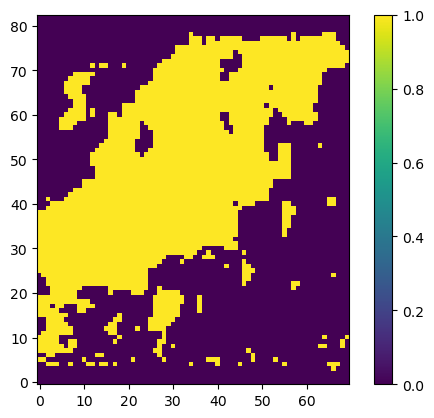

In [40]:
fit_n(1)

=== Setup ===
Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: erg/s/cm2/micron
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.
===  Fit  ===
Core 14: # spaxels fit=114
Core 13: # spaxels fit=113
Core 18: # spaxels fit=114
Core 8: # spaxels fit=113
Core 5: # spaxels fit=114
Core 1: # spaxels fit=113
Core 16: # spaxels fit=114
Core 19: # spaxels fit=113
Core 4: # spaxels fit=113Core 22: # spaxels fit=114

Core 17: # spaxels fit=113
Core 2: # spaxels fit=113
Core 15: # spaxels fit=113
Core 9: # spaxels fit=114
Core 12: # spaxels fit=113
Core 7: # spaxels fit=114
Core 11: # spaxels fit=114
Core 21: # spaxels fit=113
Core 10: # spaxels fit=113
Core 3: # spaxels fit=114
Core 20: # spaxels fit=114
Core 6: # spaxels fit=113
=== Check ===
Sorting components by wave in the upward

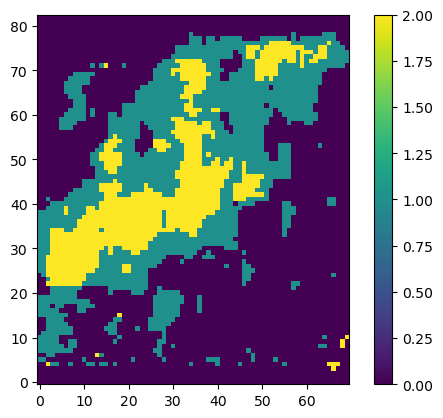

In [41]:
fit_n(2)

=== Setup ===
Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: erg/s/cm2/micron
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.
===  Fit  ===
Core 3: # spaxels fit=36
Core 6: # spaxels fit=36
Core 19: # spaxels fit=36
Core 2: # spaxels fit=36
Core 12: # spaxels fit=36
Core 7: # spaxels fit=36
Core 1: # spaxels fit=35
Core 14: # spaxels fit=36
Core 22: # spaxels fit=36
Core 21: # spaxels fit=36
Core 18: # spaxels fit=36
Core 13: # spaxels fit=36
Core 10: # spaxels fit=36
Core 16: # spaxels fit=36
Core 4: # spaxels fit=36
Core 5: # spaxels fit=36
Core 11: # spaxels fit=36
Core 20: # spaxels fit=36
Core 8: # spaxels fit=36
Core 17: # spaxels fit=36
Core 15: # spaxels fit=36
Core 9: # spaxels fit=36
=== Check ===
Sorting components by wave in the upward direction.
        No

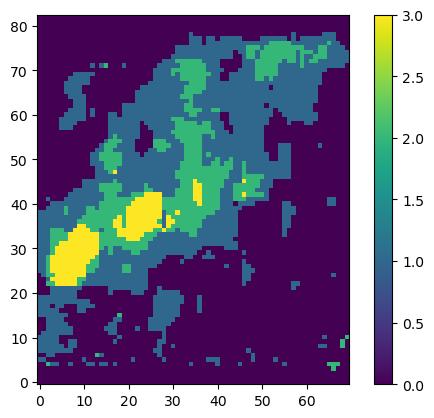

In [42]:
fit_n(3)

=== Setup ===
Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: erg/s/cm2/micron
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.
===  Fit  ===
Core 2: # spaxels fit=9
Core 12: # spaxels fit=9
Core 19: # spaxels fit=9Core 13: # spaxels fit=9

Core 8: # spaxels fit=9
Core 20: # spaxels fit=9
Core 15: # spaxels fit=9
Core 5: # spaxels fit=9
Core 11: # spaxels fit=9
Core 10: # spaxels fit=9
Core 17: # spaxels fit=9
Core 22: # spaxels fit=10
Core 16: # spaxels fit=9
Core 1: # spaxels fit=9
Core 9: # spaxels fit=9
Core 14: # spaxels fit=9Core 4: # spaxels fit=9

Core 21: # spaxels fit=9
Core 7: # spaxels fit=9
Core 3: # spaxels fit=9
Core 18: # spaxels fit=9
Core 6: # spaxels fit=9
=== Check ===
Sorting components by wave in the upward direction.
q3dcollect: Saving emission-lin

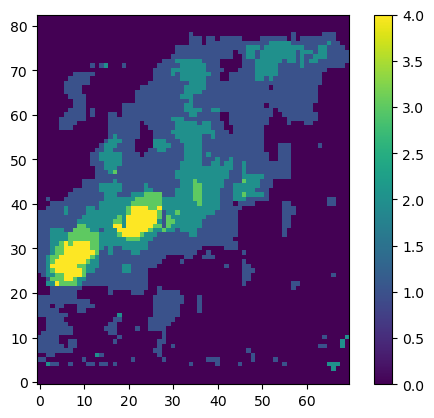

In [43]:
fit_n(4)

=== Setup ===
Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: erg/s/cm2/micron
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.
===  Fit  ===
Core 6: # spaxels fit=4
Core 8: # spaxels fit=4
Core 21: # spaxels fit=4
Core 7: # spaxels fit=5
Core 5: # spaxels fit=4
Core 18: # spaxels fit=4
Core 12: # spaxels fit=4
Core 15: # spaxels fit=4
Core 3: # spaxels fit=4
Core 10: # spaxels fit=5
Core 4: # spaxels fit=5
Core 9: # spaxels fit=4
Core 22: # spaxels fit=5
Core 17: # spaxels fit=4
Core 16: # spaxels fit=5
Core 2: # spaxels fit=4
Core 14: # spaxels fit=4
Core 20: # spaxels fit=4
Core 19: # spaxels fit=5
Core 13: # spaxels fit=5
Core 1: # spaxels fit=4
Core 11: # spaxels fit=4
=== Check ===
Sorting components by wave in the upward direction.
q3dcollect: Saving emission-line

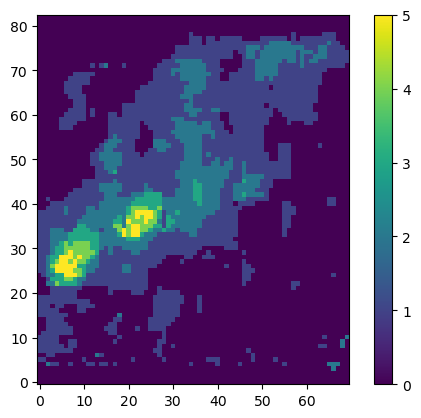

In [44]:
fit_n(5)

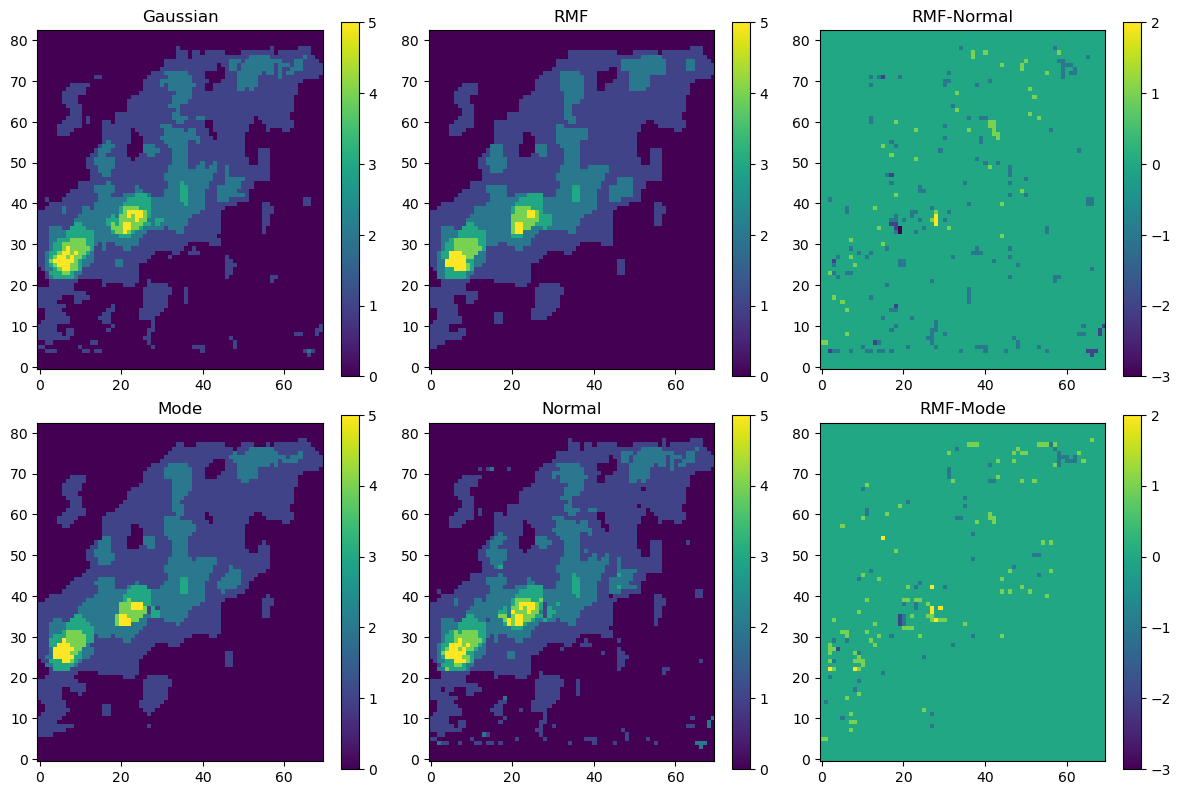

In [55]:
# plt.imshow(number_of_components.max(axis=0).T, origin="lower")
# plt.colorbar()
# np.save("noc.npy", number_of_components)
ncomp_map = number_of_components.max(axis=0)

from scipy.ndimage import gaussian_filter, generic_filter
def gaussian_rounding(data, sigma=1.0):
    smoothed = gaussian_filter(data.astype(float), sigma=sigma)
    return np.round(smoothed).astype(int)

def mode_filter(data, size=3):
    def mode_func(values):
        vals, counts = np.unique(values, return_counts=True)
        return vals[np.argmax(counts)]
    return generic_filter(data, mode_func, size=size)

from gco.pygco import cut_grid_graph_simple
def rmf_smoothing(component_map):
    max_ncomp = int(np.max(component_map)) + 1
    height, width = component_map.shape
    # penalties
    data_cost = np.zeros((height * width, max_ncomp), dtype=np.int32)
    flat_comps = component_map.flatten()
    for i in range(max_ncomp):
        data_cost[:,i] = (flat_comps != i).astype(np.int32) * 9  # bestrafung für veränderung
    data_cost = data_cost.reshape((height, width, max_ncomp))
    smooth_cost = (np.ones((max_ncomp, max_ncomp)) - np.eye(max_ncomp)) * 5  # bestrafung für nachbarn
    smooth_cost = smooth_cost.astype(np.int32)
    # rmf
    result = cut_grid_graph_simple(data_cost, smooth_cost)
    components_rmf = result.reshape((height, width))
    return components_rmf

gaussian_map = gaussian_rounding(ncomp_map, sigma=0.57)
mode_map = mode_filter(ncomp_map, size=3)
rmf_map = rmf_smoothing(ncomp_map)
fig, ax = plt.subplots(2, 3, figsize=(12,8))

im0 = ax[0,0].imshow(gaussian_map.T, origin="lower")
ax[0,0].set_title("Gaussian")
plt.colorbar(im0, ax=ax[0,0])
im1 = ax[1,0].imshow(mode_map.T, origin="lower")
ax[1,0].set_title("Mode")
plt.colorbar(im1, ax=ax[1,0])
im2 = ax[0,1].imshow(rmf_map.T, origin="lower", vmin=0)
ax[0,1].set_title("RMF")
plt.colorbar(im2, ax=ax[0,1])
im3 = ax[1,1].imshow(ncomp_map.T, origin="lower")
ax[1,1].set_title("Normal")
plt.colorbar(im3, ax=ax[1,1])
im4 = ax[0,2].imshow(rmf_map.T-ncomp_map.T, origin="lower")
plt.colorbar(im4, ax=ax[0,2])
ax[0,2].set_title("RMF-Normal")
im5 = ax[1,2].imshow(rmf_map.T-mode_map.T, origin="lower", vmin=-3)
plt.colorbar(im5, ax=ax[1,2])
ax[1,2].set_title("RMF-Mode")
plt.tight_layout()
plt.show()

In [ ]:
# np.save("smoothed_mode_map.npy", mode_map)
# np.save("smoothed_rmf_map.npy", rmf_map)
# np.save("smoothed_gaussian.npy", gaussian_map)

In [ ]:
# combine optimal fits
import os
import shutil
outdir_final = outdir_conv + "_final"
if not os.path.exists(outdir_final):
    os.makedirs(outdir_final)
for file in os.listdir(outdir_final):
    path = os.path.join(outdir_final, file)
    os.unlink(path)

try:
    final_components = number_of_components.max(axis=0)
except NameError:
    number_of_components = np.load("noc.npy")
    final_components = number_of_components.max(axis=0)
it = np.nditer(final_components, flags=["multi_index"])
for i, x in enumerate(it):
    if x == 0:
        continue
    file = label_conv+f"_{it.multi_index[0]+1:04d}_{it.multi_index[1]+1:04d}.npy"
    src = os.path.join(outdir_conv+str(int(x)), file)
    try:
        shutil.copy2(src, outdir_final)
    except FileExistsError:
        ...

q3di = q3din(infile, label_conv, argsreadcube={"wmapext": None}, outdir=outdir_final)
q3di.name = label_conv
q3di.zsys_gas = redshift
q3di.fitrange = fitrange
cube = q3di.load_cube()
q3di.init_linefit(lines, linetie='[OIII]5007', maxncomp=5)
q3di.init_contfit("fitpoly")
# q3di.argscontfit.update({"fitord": 1})
# q3di.maskwidths_def = 5000
# q3di.masksig_secondfit = 4
q3dcollect(q3di, compsortpar="flux")

Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: MJy/sr
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.
Sorting components by flux in the upward direction.
        No data for [1, 1]
        No data for [1, 2]
        No data for [1, 3]
        No data for [1, 4]
        No data for [1, 5]
        No data for [1, 7]
        No data for [1, 12]
        No data for [1, 13]
        No data for [1, 14]
        No data for [1, 15]
        No data for [1, 21]
        No data for [1, 22]
        No data for [1, 23]
        No data for [1, 24]
        No data for [1, 25]
        No data for [1, 40]
        No data for [1, 41]
        No data for [1, 42]
        No data for [1, 43]
        No data for [1, 44]
        No data for [1, 45]
        No data for [1, 46]
        No data

In [59]:
def read_npz(datafile=''):
    ''' Load binary line data file.

    Parameters
    ----------
    datafile : str

    Returns
    -------
    Contents of datafile.

    '''
    dataread = np.load(datafile, allow_pickle=True)

    emlflx = dataread['emlflx'].item()
    emlflxerr = dataread['emlflxerr'].item()
    emlncomp = dataread['emlncomp'].item()
    emlsig = dataread['emlsig'].item()
    emlsigerr = dataread['emlsigerr'].item()
    emlwav = dataread['emlwav'].item()
    emlwaverr = dataread['emlwaverr'].item()
    emlweq = dataread['emlweq'].item()
    ncols = dataread['ncols'].item()
    nrows = dataread['nrows'].item()

    return emlflx, emlflxerr, emlncomp, emlsig, emlsigerr, emlwav, emlwaverr, emlweq, ncols, nrows

In [73]:
def init_fit_from_map(map):
    # set up directories
    outdir_n = outdir + "_from_map/"
    if not os.path.exists(outdir_n):
        os.makedirs(outdir_n)
    logdir_n = logdir + "_from_map/"
    if not os.path.exists(logdir_n):
        os.makedirs(logdir_n)

    logfile = os.path.join(logdir_n, label+"-fitlog.txt")
    q3di = q3din(infile, label, outdir=outdir_n, logfile=logfile)
    q3di.argsreadcube = {"wmapext": None, "fluxnorm": 1e-17, "usebunit": True}
    cube = q3di.load_cube()
    q3di.name = label
    q3di.zsys_gas = redshift
    q3di.fitrange = fitrange

    # line fit
    maxncomp=int(map.max())
    q3di.init_linefit(lines, linetie='[OIII]5007', maxncomp=maxncomp, checkcomp=False)
    q3di.spect_convol['ws_instrum'] = {'JWST_NIRSPEC':['G235H']}
    q3di.siglim_gas = np.array([40., 1000.])
    # q3di.argslineinit['flxlim'] = np.array([0., 1e-14]) / cube.fluxnorm
    q3di.argslinefit['method'] = 'least_squares'
    q3di.argslinefit['ftol'] = 1.e-8
    q3di.argslinefit['gtol'] = 1.e-8
    q3di.argslinefit['xtol'] = 1.e-8
    q3di.argslinefit['x_scale'] = 'jac'
    q3di.argslinefit['tr_solver'] = 'lsmr'

    q3di.argscheckcomp['sigcut'] = 3.
    q3di.argscheckcomp['ignore']= ['Hbeta']
    q3di.perror_useresid = True

    q3di.snr = 3.0
    q3di.snr_thresh = None

    for line in lines:
        q3di.ncomp[line] = map.astype(int)  # read in map for number of compontents
        q3di.zinit_gas[line][:,:,:] = q3di.zsys_gas  # standard values if not specified below
        q3di.siginit_gas[line][:,:,:] = 200.

    # set inital parameters
    flx, _, _, sig, _, wav, _, _, _, _ = read_npz(os.path.join(outdir_final, label_conv+".line.npz"))

    for i in range(maxncomp-1):
        for line, line_wavelength in zip(lines, line_wavelengths):
            
            init_wav = micron_to_redshift(wav[f"c{i+1}"][line], line_wavelength)
            nanmask = ~np.isnan(init_wav)
            q3di.zinit_gas[line][:,:,i][nanmask] = init_wav[nanmask]

            init_sig = sig[f"c{i+1}"][line]
            nanmask = ~np.isnan(init_sig)
            q3di.siginit_gas[line][:,:,i][nanmask] = init_sig[nanmask]

        # plt.imshow(init_val.T, origin="lower")
        # plt.colorbar()
        # plt.show()
        # print(np.nanmin(init_val), np.nanmax(init_val))
        # plt.imshow(previous_data["emlwav"][None][0][f"c{i+1}"][line].T, origin="lower")
        # plt.colorbar()
        # plt.show()

    # continum fit
    # if n == 1:
    q3di.init_contfit("fitpoly")
    q3di.argscontfit.update({"fitord": 1})
    # else:
    #     q3di.init_contfit("fitpoly")
    #     q3di.docontfit = False
    q3di.maskwidths_def = 4000
    q3di.masksig_secondfit = 4

    filename_q3di = os.path.join(indir, f"q3di_{label}_from_map.npy")
    np.save(filename_q3di, q3di)
    return filename_q3di

In [76]:
filename_q3di = init_fit_from_map(rmf_map)
q3dfit(filename_q3di, onefit=True, quiet=False, ncores=ncores, nocrash=True)

Cube: No wavelength units in header; using micron
Size of data cube: [70, 83, 3815]
Wavelength range: [1.66020, 3.17054] micron
Dispersion: 0.00040 micron
Input flux units: MJy/sr
Input wave units: micron
Output flux units: erg/s/cm2/micron
Output wave units: micron
NB: q3dfit uses output units for internal calculations.
Core 14: # spaxels fit=264Core 5: # spaxels fit=264

Core 21: # spaxels fit=264
Core 10: # spaxels fit=264
Core 22: # spaxels fit=265
Core 16: # spaxels fit=264
Core 20: # spaxels fit=264
Core 15: # spaxels fit=264
Core 1: # spaxels fit=264
Core 8: # spaxels fit=264
Core 12: # spaxels fit=264
Core 19: # spaxels fit=264
Core 4: # spaxels fit=264
Core 3: # spaxels fit=264
Core 18: # spaxels fit=264
Core 9: # spaxels fit=264
Core 2: # spaxels fit=264
Core 13: # spaxels fit=264
Core 7: # spaxels fit=264
Core 6: # spaxels fit=264
Core 11: # spaxels fit=265
Core 17: # spaxels fit=264


In [77]:
q3dcollect(filename_q3di, compsortpar="wave", quiet=True)

Sorting components by wave in the upward direction.
        No data for [1, 1]
        No data for [1, 2]
        No data for [1, 3]
        No data for [1, 4]
        No data for [1, 5]
        No data for [1, 70]
        No data for [1, 71]
        No data for [1, 72]
        No data for [1, 73]
        No data for [1, 74]
        No data for [1, 75]
        No data for [1, 76]
        No data for [1, 77]
        No data for [1, 78]
        No data for [1, 79]
        No data for [1, 80]
        No data for [1, 81]
        No data for [1, 82]
        No data for [1, 83]
        No data for [2, 1]
        No data for [2, 2]
        No data for [2, 3]
        No data for [2, 4]
        No data for [2, 5]
        No data for [2, 70]
        No data for [2, 71]
        No data for [2, 72]
        No data for [2, 73]
        No data for [2, 74]
        No data for [2, 75]
        No data for [2, 76]
        No data for [2, 77]
        No data for [2, 78]
        No data for [2, 79]
      

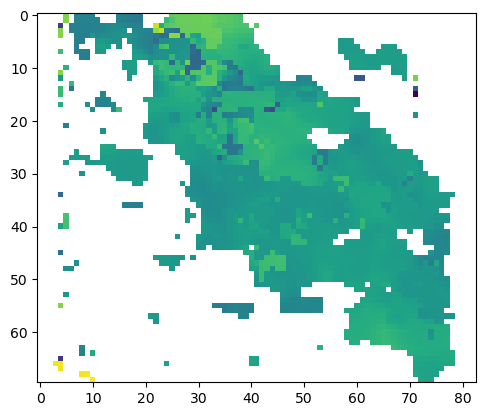

In [57]:
data = np.load("output_conv_final/4C1971_conv.line.npz", allow_pickle=True)
np.isnan(data["emlwav"][None][0]["c1"]["[OIII]5007"]).all()
plt.imshow(data["emlwav"].item()["c1"]["[OIII]5007"])

In [58]:
data = np.load("output_conv_final/4C1971_conv_0040_0040.npy", allow_pickle=True)
data[None][0].param

{'lbOIIIrb5007_1_SPECRES': <q3dfit.spectConvol.spectConvol at 0x7fe80fd5dca0>,
 'lbOIIIrb5007_1_flx': np.float64(69.71211620732896),
 'lbOIIIrb5007_1_cwv': np.float64(2.29836684636755),
 'lbOIIIrb5007_1_sig': np.float64(86.7292928104175),
 'lbOIIIrb5007_0_SPECRES': <q3dfit.spectConvol.spectConvol at 0x7fe80fd5dca0>,
 'lbOIIIrb5007_0_flx': np.float64(33.57764877826167),
 'lbOIIIrb5007_0_cwv': np.float64(2.2995206610432373),
 'lbOIIIrb5007_0_sig': np.float64(288.62527408912354),
 'lbOIIIrb4959_1_SPECRES': <q3dfit.spectConvol.spectConvol at 0x7fe80fd5dca0>,
 'lbOIIIrb4959_1_flx': np.float64(23.237372069109654),
 'lbOIIIrb4959_1_cwv': np.float64(2.2763649719124475),
 'lbOIIIrb4959_1_sig': np.float64(86.7292928104175),
 'lbOIIIrb4959_0_SPECRES': <q3dfit.spectConvol.spectConvol at 0x7fe80fd5dca0>,
 'lbOIIIrb4959_0_flx': np.float64(11.19254959275389),
 'lbOIIIrb4959_0_cwv': np.float64(2.2775077413167155),
 'lbOIIIrb4959_0_sig': np.float64(288.62527408912354),
 'Hbeta_1_SPECRES': <q3dfit.spect